Project: Diabetes Prediction Using ML

Dataset:diabetes.csv

**1. Setup**

In [23]:
# install the required Libraries from "requirements.txt"
# %pip install -q -r requirements.txt|

In [24]:
# Importing The Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    recall_score,
    f1_score
)

In [25]:
# configurations
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
sns.set_theme(style="darkgrid")

RANDOM_STATE = 40
TARGET_COL = "Outcome"
CSV_PATH = "../dataset/diabetes.csv"

**2. Load Data**

In [26]:
df = pd.read_csv(CSV_PATH)

In [27]:
print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.600,0.627,50,1
1,1,85,66,29,0,26.600,0.351,31,0
2,8,183,64,0,0,23.300,0.672,32,1
3,1,89,66,23,94,28.100,0.167,21,0
4,0,137,40,35,168,43.100,2.288,33,1


**3. Exploratory Data Analysis**

In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


**9 Numerical Column and no Categeorical Column**

In [29]:
# missing values
df.isna().sum().sort_values()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [30]:
# Quick check for encoded missing values
for col in df.columns:
    print(df[col].value_counts().head(5))

Pregnancies
1    135
0    111
2    103
3     75
4     68
Name: count, dtype: int64
Glucose
100    17
99     17
125    14
111    14
106    14
Name: count, dtype: int64
BloodPressure
70    57
74    52
78    45
68    45
72    44
Name: count, dtype: int64
SkinThickness
0     227
32     31
30     27
27     23
23     22
Name: count, dtype: int64
Insulin
0      374
105     11
140      9
130      9
120      8
Name: count, dtype: int64
BMI
32.000    13
31.600    12
31.200    12
0.000     11
32.400    10
Name: count, dtype: int64
DiabetesPedigreeFunction
0.254    6
0.258    6
0.261    5
0.207    5
0.268    5
Name: count, dtype: int64
Age
22    72
21    63
25    48
24    46
23    38
Name: count, dtype: int64
Outcome
0    500
1    268
Name: count, dtype: int64


>Inference: Some columns have missing values encoded as Zero(0)

In [31]:
# identify columns with zero values
zero_summary = (
    df.eq(0).sum().to_frame(name="zero_count").assign(zero_percentage=lambda x: (x["zero_count"] / len(df)) * 100)
)

zero_summary

,zero_count,zero_percentage
Pregnancies,111,14.453
Glucose,5,0.651
BloodPressure,35,4.557
SkinThickness,227,29.557
Insulin,374,48.698
BMI,11,1.432
DiabetesPedigreeFunction,0,0.000
Age,0,0.000
Outcome,500,65.104


>Inference: in this dataset, Pregnencies can legitimately have a value of 0, while (Glucose, BloodPresure, SkinThickness, Insulin and BMI) having 0 is physiologically invalid and therefore they represent missing values. The zero values needs to be imputed with either mean/median value. (after train test split)

In [32]:
# duplicates
duplicate_mask = df.duplicated()
num_duplicates = duplicate_mask.sum()
print("Number of Duplicate rows:", num_duplicates)



Number of Duplicate rows: 0


In [33]:
# target column distribution
print(df[TARGET_COL].value_counts())

print("-"*50)

print(df[TARGET_COL].value_counts(normalize=True))

Outcome
0    500
1    268
Name: count, dtype: int64
--------------------------------------------------
Outcome
0   0.651
1   0.349
Name: proportion, dtype: float64


**Targets:**
- 0 - non-diabetic
- 1 - diabetic

**NOTE**: There is some imbalance, so we will pay attention to recall/f1_score and use class weighting

In [34]:
# imbalanc ratio
n_diabetic = (df[TARGET_COL] == 1).sum()
n_non_diabetic = (df[TARGET_COL] == 0).sum()

print("Imbalance Ratio (Non-DIabetic : Diabetic) =", round(n_non_diabetic / max(n_diabetic, 1), 2))

Imbalance Ratio (Non-DIabetic : Diabetic) = 1.87


In [35]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000,768.000,768.000,768.000,768.000,768.000,768.000,768.000,768.000
mean,3.845,120.895,69.105,20.536,79.799,31.993,0.472,33.241,0.349
std,3.370,31.973,19.356,15.952,115.244,7.884,0.331,11.760,0.477
min,0.000,0.000,0.000,0.000,0.000,0.000,0.078,21.000,0.000
25%,1.000,99.000,62.000,0.000,0.000,27.300,0.244,24.000,0.000
50%,3.000,117.000,72.000,23.000,30.500,32.000,0.372,29.000,0.000
75%,6.000,140.250,80.000,32.000,127.250,36.600,0.626,41.000,1.000
max,17.000,199.000,122.000,99.000,846.000,67.100,2.420,81.000,1.000


**Data Visualization**

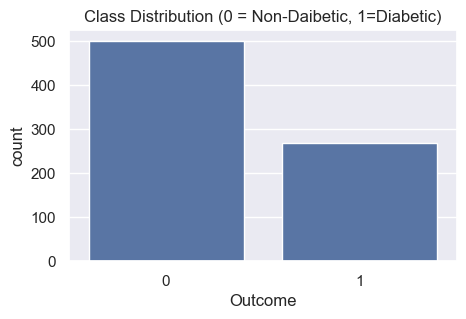

In [36]:
# Visualize class imbalance
plt.figure(figsize=(5,3))
sns.countplot(x=TARGET_COL, data=df)
plt.title("Class Distribution (0 = Non-Daibetic, 1=Diabetic)")
plt.show()

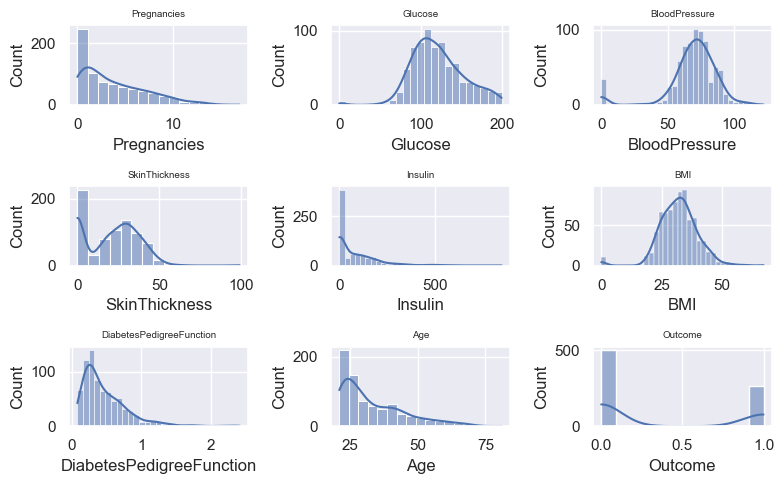

In [37]:
# Histogram plot - distribution
fig, axes = plt.subplots(3, 3, figsize=(8,5))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(col, fontsize=7)

plt.tight_layout()
plt.show()

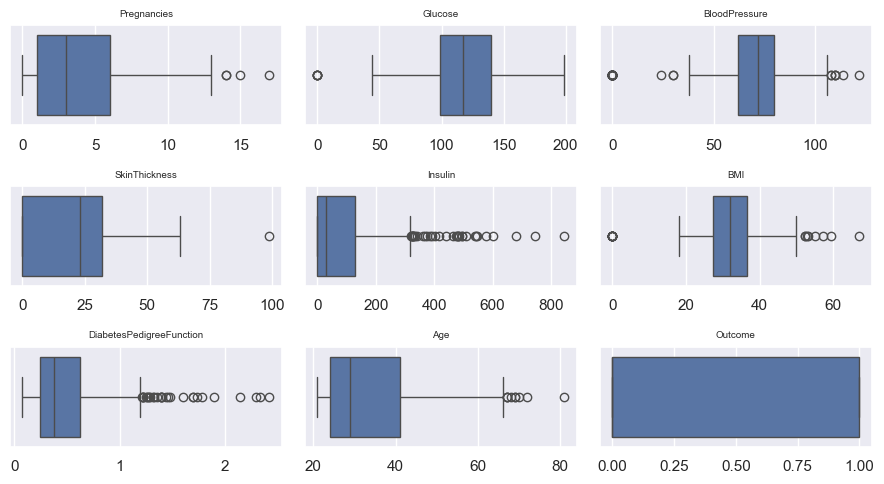

In [38]:
# Outlier analsis - boxplot
fig, axes = plt.subplots(3, 3, figsize=(9,5))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col, fontsize=7)
    axes[i].set_xlabel("")

plt.tight_layout()
plt.show()

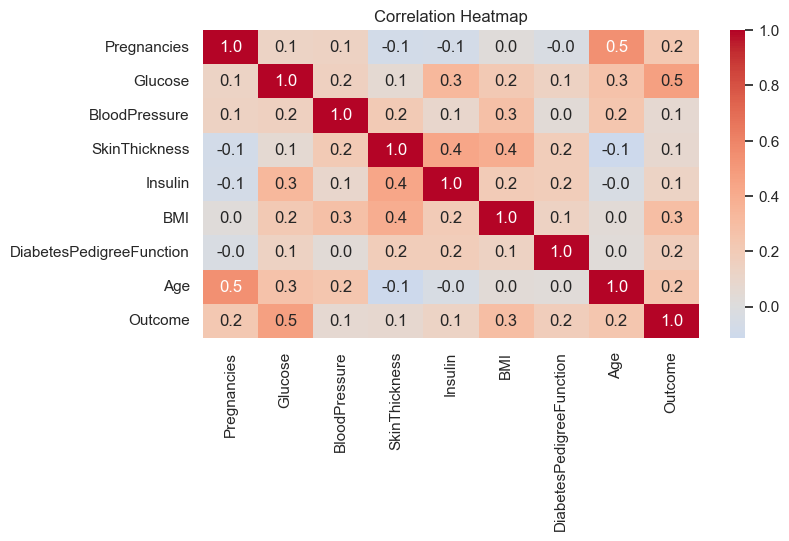

In [39]:
# identify presence of highly correlated columns & Features relationships
plt.figure(figsize=(8,4))
sns.heatmap(
    df.corr(),
    cmap="coolwarm",
    annot=True,
    fmt=".1f",
    center=0
)

plt.title("Correlation Heatmap")
plt.show()

**No Presence of Highly Correlated Column**

**4. Data Preprocessing**

In [40]:
# seperating int features and target
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

In [41]:
# Tarain Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

In [42]:
print("Dataset Shape:", X.shape)
print("Train Dataset Shape:", X_train.shape)
print("Test Dataset Shape:", X_test.shape)

Dataset Shape: (768, 8)
Train Dataset Shape: (614, 8)
Test Dataset Shape: (154, 8)


**Preprocessing Pipeline**

In [45]:
# changing the 0 values to NAN for selected columns ----> Median imutation
zero_as_missing_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

numerical_feature = X_train.select_dtypes(include=[np.number]).columns.tolist()


# Replace 0 --> NaN for selected columns in a pandas dataframe, Returns a new Dataframe (safe for sklearn pipeline)
def replace_zeros_with_nan_df(X, cols):
    X=X.copy()
    for col in cols:
        if col in X.columns:
            X[col] = X[col].replace(0, np.nan)
    return X

zero_to_nan = FunctionTransformer(
    replace_zeros_with_nan_df,
    kw_args={"cols": zero_as_missing_cols},
    validate=False
)

numerical_transformer = Pipeline(
    steps=[
        ("zero_to_nan", zero_to_nan),
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_feature)
    ]
)

**5. Baseline Model - Logistic Regression**

In [46]:
# Baseline model with preprocessing
baseline_pipe = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", LogisticRegression())
    ]
)

In [47]:
# Training the pipeline
baseline_pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse ma

In [48]:
# Evaluation Function - Reuseable
def evaluate_classifier(model, X_train, y_train, X_test, y_test, model_name):
    # Prediction
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # accuracy
    train_acc = accuracy_score(y_train, y_train_pred) * 100
    test_acc = accuracy_score(y_test, y_test_pred) * 100

    # Results
    print(f"{model_name} - Train Accuracy: {train_acc:.2f}%")
    print(f"{model_name} - Test Accuracy: {test_acc:.2f}%")

    print("-"*50)

    print("Train Classification Report")
    print(classification_report(y_train, y_train_pred))

    print("-"*50)

    print("Test Classificatin Report")
    print(classification_report(y_test, y_test_pred))

In [49]:
evaluate_classifier(
    model=baseline_pipe,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    model_name="Baseline Logistic Regression"
)

Baseline Logistic Regression - Train Accuracy: 78.18%
Baseline Logistic Regression - Test Accuracy: 75.32%
--------------------------------------------------
Train Classification Report
              precision    recall  f1-score   support

           0       0.80      0.89      0.84       400
           1       0.74      0.57      0.65       214

    accuracy                           0.78       614
   macro avg       0.77      0.73      0.74       614
weighted avg       0.78      0.78      0.77       614

--------------------------------------------------
Test Classificatin Report
              precision    recall  f1-score   support

           0       0.79      0.85      0.82       100
           1       0.67      0.57      0.62        54

    accuracy                           0.75       154
   macro avg       0.73      0.71      0.72       154
weighted avg       0.75      0.75      0.75       154



**Low Performance on class 1. Average Overall Score**

**6. Model Sleection and Optimization**

In [50]:
# scalepos weight--> (negative samples) / (positive samples)
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / max(pos, 1)

print("Scale_pos_weight:", scale_pos_weight)

Scale_pos_weight: 1.8691588785046729


In [51]:
# models to try
models= {
    "LogisticRegression": Pipeline(
        [
            ("preprocess", preprocess),
            ("model", LogisticRegression(
                random_state=RANDOM_STATE,
                class_weight="balanced",
                max_iter=1000
            ))
        ]
    ),
    "SVC": Pipeline(
        [
            ("preprocess", preprocess),
            ("model", SVC(
                random_state=RANDOM_STATE,
                class_weight="balanced"
            ))
        ]
    ),
    "RandomForest": Pipeline(
        [
            ("preprocess", preprocess),
            ("model", RandomForestClassifier(
                random_state=RANDOM_STATE,
                class_weight="balanced_subsample"
            ))
        ]
    ),
    "XGBClassifier": Pipeline(
        [
            ("preprocess", preprocess),
            ("model", XGBClassifier(
                scale_pos_weight=scale_pos_weight,
                eval_metric="logloss"
            ))
        ]
    )
}

In [52]:
k=5
cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=RANDOM_STATE)

In [54]:
for name, model_pipeline in models.items():
    recall_scores = []
    f1_scores = []

    for tr_idx, te_idx in cv.split(X_train, y_train):
        X_tr, X_te = X_train.iloc[tr_idx], X_train.iloc[te_idx]
        y_tr, y_te = y_train.iloc[tr_idx], y_train.iloc[te_idx]

        model_pipeline.fit(X_tr, y_tr)
        pred = model_pipeline.predict(X_te)

        recall_scores.append(round(recall_score(y_te, pred), 2))
        f1_scores.append(round(f1_score(y_te, pred), 2))

    print("Model Name:", name)
    print("Recall Values:", recall_scores)
    print("F1 Scores:", f1_scores)
    print("\nCV Recall mean:", round(float(np.mean(recall_scores)), 4))
    print("CV F1 Score Mean:", round(float(np.mean(f1_scores)), 4))
    print("-"*50)

    # cross validation is a more reliable validation technique

Model Name: LogisticRegression
Recall Values: [0.7, 0.72, 0.58, 0.81, 0.79]
F1 Scores: [0.65, 0.68, 0.62, 0.71, 0.7]

CV Recall mean: 0.72
CV F1 Score Mean: 0.672
--------------------------------------------------
Model Name: SVC
Recall Values: [0.77, 0.72, 0.67, 0.79, 0.79]
F1 Scores: [0.71, 0.66, 0.67, 0.66, 0.68]

CV Recall mean: 0.748
CV F1 Score Mean: 0.676
--------------------------------------------------
Model Name: RandomForest
Recall Values: [0.6, 0.63, 0.6, 0.58, 0.62]
F1 Scores: [0.64, 0.68, 0.71, 0.6, 0.68]

CV Recall mean: 0.606
CV F1 Score Mean: 0.662
--------------------------------------------------
Model Name: XGBClassifier
Recall Values: [0.58, 0.67, 0.56, 0.53, 0.71]
F1 Scores: [0.6, 0.66, 0.61, 0.53, 0.66]

CV Recall mean: 0.61
CV F1 Score Mean: 0.612
--------------------------------------------------


**Inference: SVC(Support Vector Classifier) has better Performance**

**Hyperparameter Tunning**

In [55]:
svc_pipe = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", SVC(
            class_weight="balanced",
            random_state=RANDOM_STATE
        ))
    ]
)

In [101]:
# Param Distribution
param_grid_svc = {
    "model__C": [0.05, 0.1, 1, 10, 100, 10000],
    "model__gamma": [0.001, 0.01, 0.1, 1, "scale"]
}

In [102]:
# Grid Search
grid_search = GridSearchCV(
    estimator=svc_pipe,
    param_grid=param_grid_svc,
    scoring="f1",
    cv=cv,
    verbose=True,
    n_jobs=-1
)

In [103]:
# Performing gridsearchcv
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=40))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.05, 0.1, ...], 'model__gamma': [0.001, 0.01, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2

In [104]:
print("Hyperparameter Tuning Results:")
print("Best Params:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

Hyperparameter Tuning Results:
Best Params: {'model__C': 10000, 'model__gamma': 0.001}
Best Score: 0.7011989459815546


**7. Retrain with best Params**

In [111]:
best_pipe = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", SVC(
            random_state=RANDOM_STATE,
            class_weight="balanced",
            C=1,
            gamma="scale"
        ))
    ]
)

In [112]:
best_pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse ma

**8. Model Evaluation**

In [113]:
evaluate_classifier(
    model=best_pipe,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    model_name="Best SVC"
)

Best SVC - Train Accuracy: 82.08%
Best SVC - Test Accuracy: 73.38%
--------------------------------------------------
Train Classification Report
              precision    recall  f1-score   support

           0       0.91      0.80      0.85       400
           1       0.70      0.86      0.77       214

    accuracy                           0.82       614
   macro avg       0.81      0.83      0.81       614
weighted avg       0.84      0.82      0.82       614

--------------------------------------------------
Test Classificatin Report
              precision    recall  f1-score   support

           0       0.86      0.70      0.77       100
           1       0.59      0.80      0.68        54

    accuracy                           0.73       154
   macro avg       0.73      0.75      0.73       154
weighted avg       0.77      0.73      0.74       154



In [123]:
def predict_diabetes(input_features):
    input_df = pd.DataFrame(
        [input_features],
        columns=X_train.columns
    )
    prediction = best_pipe.predict(input_df)
    print("Model prediction:", prediction)
    if prediction[0] == 1:
        print("Diagnosis - Diabetic 🔴")
    else:
        print("Diagnosis - Non-Diabetic 🟢")

In [124]:
y_test[y_test==1].head()

129    1
264    1
425    1
259    1
706    1
Name: Outcome, dtype: int64

In [125]:
y_test[y_test==0].head()

20     0
153    0
531    0
144    0
167    0
Name: Outcome, dtype: int64

In [126]:
# sample unknown data point - access from test data index
test_1 = X_test.loc[129].tolist()
print(test_1)

[0.0, 105.0, 84.0, 0.0, 0.0, 27.9, 0.741, 62.0]


In [127]:
predict_diabetes(test_1)

Model prediction: [0]
Diagnosis - Non-Diabetic 🟢


>**Important Note:** This is a strong and realistic performance for this dataset. Even with correct preprocessing, cross-validation, and model tuning, some predictions will still be wrong. No model can achieve 100% accuracy on this problem because the dataset itself has overlapping patterns and noise, which creates a natural performance ceiling. While further improvements are possible through advanced techniques, this result is a solid and trustworthy stopping point for our current approach.
